In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Measured by Sunasheer: Breath in normally → hold breath for around 10s → exhale fast → repeat 10 times

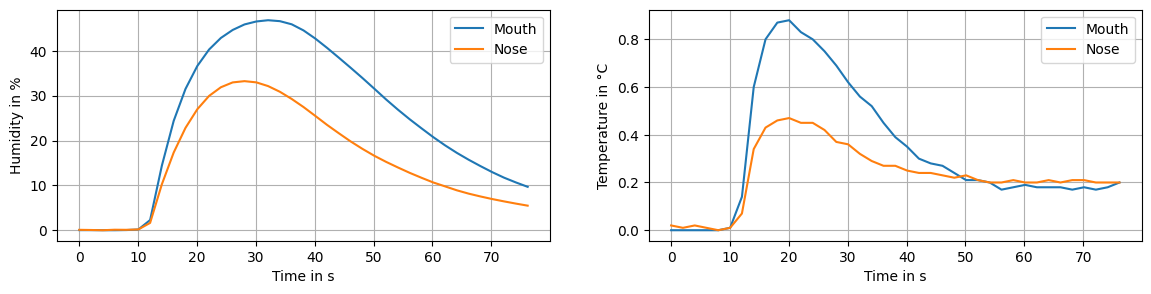

In [3]:
def get_cir(region):
    # load data
    data_all = []
    for i in range(1, 11):
        data = np.loadtxt(f'{os.path.abspath(os.path.join(os.getcwd(), os.pardir))}/data/cir/{region}_trial_{i}.dat', delimiter=',', skiprows=1)
        data_all.append(data)

    # mean over trials
    cir_mean = np.mean(data_all, axis=0)

    # baseline correction
    baseline_humidity = np.min(cir_mean[:, 1])
    baseline_temperature = np.min(cir_mean[:, 2])
    cir_mean[:, 1] -= baseline_humidity
    cir_mean[:, 2] -= baseline_temperature

    return cir_mean

# get cir
cir_mouth = get_cir('mouth')
cir_nose = get_cir('nose')

# plot
fig, ax = plt.subplots(1, 2, figsize=(14, 3))
ax[0].plot(cir_mouth[:, 0]/1000, cir_mouth[:, 1], label='Mouth')
ax[0].plot(cir_nose[:, 0]/1000, cir_nose[:, 1], label='Nose')
ax[0].set_xlabel('Time in s')
ax[0].set_ylabel('Humidity in %')
ax[0].grid()
ax[0].legend()

ax[1].plot(cir_mouth[:, 0]/1000, cir_mouth[:, 2], label='Mouth')
ax[1].plot(cir_nose[:, 0]/1000, cir_nose[:, 2], label='Nose')
ax[1].set_xlabel('Time in s')
ax[1].set_ylabel('Temperature in °C')
ax[1].grid()
ax[1].legend()
plt.show()

Jamali Paper: advection-diffusion model with uniform flow from equation (51)

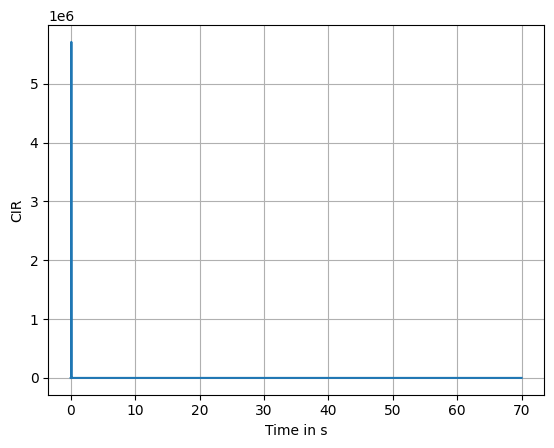

In [ ]:
def cir(t, D, d0, v_parallel, v_perp, V_rx):
    normalization = V_rx / (4 * np.pi * D * t) ** (3/2)
    exponent_numerator = (v_perp * t)**2 + (d0 - v_parallel * t)**2
    exponent = -exponent_numerator / (4 * D * t)
    cir = normalization * np.exp(exponent)
    return cir

# params
D = 2.5e-5          # Diffusion coefficient for water vapor in air [m^2/s] TODO: adjust
d0 = 0.03           # 0.03m
v_parallel = 0.3    # velocity towards sensor [m/s] TODO: adjust
v_perp = 0.0        # perpendicular flow component [m/s]
V_rx = 1.0          # volume of sensor

# time vector
t = np.linspace(0, 70, 100000)
mask = t > 0
t_valid = t[mask]

# plotting
plt.figure()
plt.plot(t_valid, cir(t_valid, D, d0, v_parallel, v_perp, V_rx))
plt.xlabel('Time in s')
plt.ylabel('CIR')
plt.grid()
plt.xlim([0, 1])
plt.show()

Sensor Response: often modelled with first-order linear system

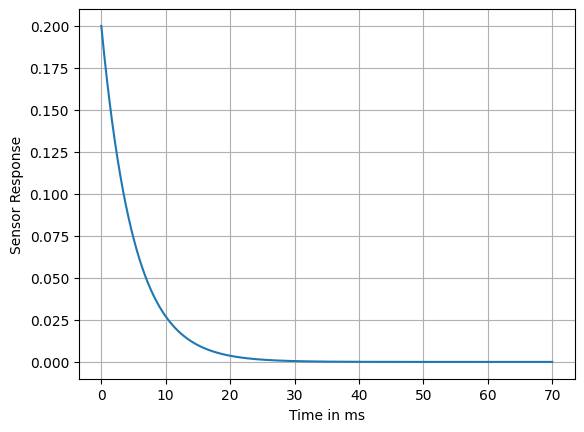

In [4]:
def sensor_response(t, tau):
    return (1 / tau) * np.exp(-t / tau)

plt.figure()
plt.plot(t, sensor_response(t, tau=5))
plt.xlabel('Time in ms')
plt.ylabel('Sensor Response')
plt.grid()
plt.show()

Since the measurement of the cir is not done with a perfect dirac we need to introduce a simpel emission model.

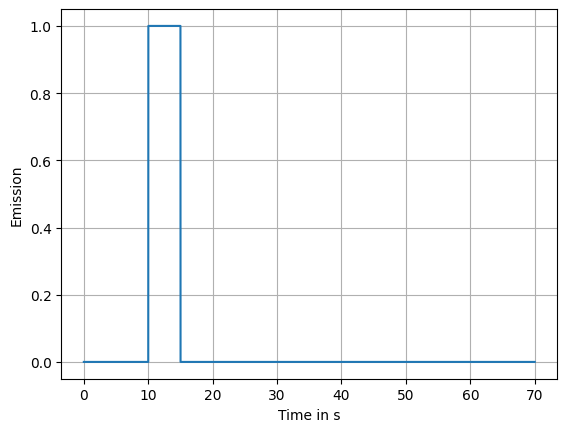

In [5]:
def emission(t, t0, T, q):
    return np.where((t >= t0) & (t <= t0 + T), q, 0.0)

plt.figure()
plt.plot(t, emission(t, t0=10, T=5, q=1.0))
plt.xlabel('Time in s')
plt.ylabel('Emission')
plt.grid()
plt.show()

Convolve cir with sensor response and emission profil to get system response

/var/folders/m0/905_fhw57xq6x9rdt2gw2q380000gn/T/ipykernel_80874/610301184.py:2: RuntimeWarning: divide by zero encountered in divide
  normalization = V_rx / (4 * np.pi * D * t) ** (3/2)
/var/folders/m0/905_fhw57xq6x9rdt2gw2q380000gn/T/ipykernel_80874/610301184.py:4: RuntimeWarning: divide by zero encountered in divide
  exponent = -exponent_numerator / (4 * D * t)
/var/folders/m0/905_fhw57xq6x9rdt2gw2q380000gn/T/ipykernel_80874/610301184.py:5: RuntimeWarning: invalid value encountered in multiply
  cir = normalization * np.exp(exponent)


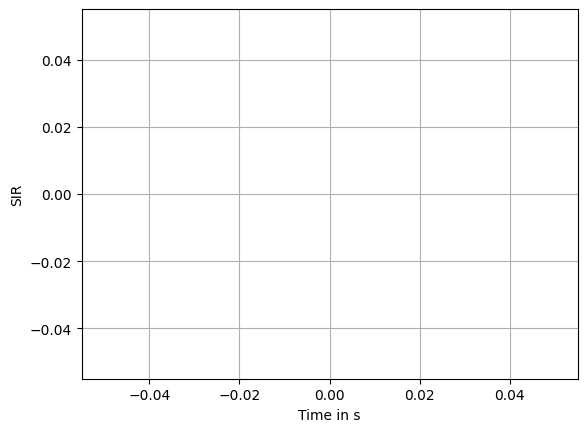

In [6]:
def sir(t, tau, gain, offset, t0, T, q):
    dt = t[1] - t[0]
    
    h_cir = cir(t)
    h_sensor = sensor_response(t, tau)
    h_sys = np.convolve(h_cir, h_sensor, mode="same") * dt

    emission_profil = emission(t, t0, T, q)
    sir = np.convolve(emission_profil, h_sys, mode="same") * dt

    return gain * sir + offset

plt.figure()
plt.plot(t, sir(t, tau=5, gain=1, offset=0, t0=10, T=5, q=1.0)[0:len(t)])
plt.xlabel('Time in s')
plt.ylabel('SIR')
plt.grid()
plt.show()

fit measurements to theoretical response

/var/folders/m0/905_fhw57xq6x9rdt2gw2q380000gn/T/ipykernel_8774/2726061898.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


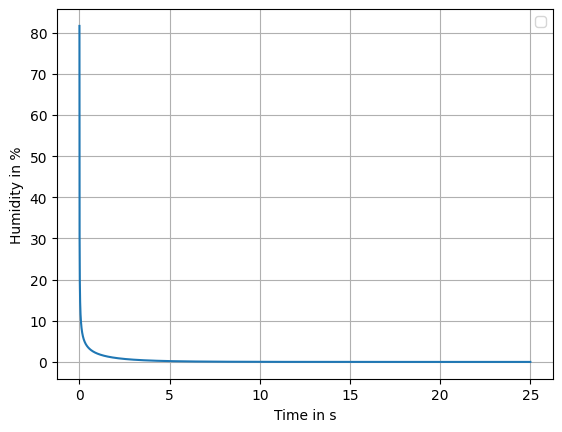

In [ ]:
def fit_cir(t, a, b, c, d):
    return a / np.sqrt(t) * np.exp(-b * (d - c * t)**2 / t)

t = np.linspace(0.001, 25, 100000)
a = 3
b = 1.3e-4
c = 54
d = 1
plt.figure()
plt.plot(t, fit_cir(t, 2.9, 1.3e-4, 54, 1), label='Test CIR')
# plt.plot(cir_mouth[:, 0]/1000, cir_mouth[:, 1], label='Measured CIR Mouth')
# plt.plot(t_valid, fit_cir(t_valid, *popt), label='Fitted CIR Mouth')
plt.xlabel('Time in s')
plt.ylabel('Humidity in %')
plt.grid()
plt.legend()
plt.show()